In [1]:
import magpylib as magpy
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from scipy.spatial import ConvexHull
from scipy.spatial import cKDTree


## Functions

In [2]:
def translate(array,x,y,z):
    vec=np.array(([x],[y],[z])).T
    array=array+vec
    return array

In [3]:
def mirror(array,plane):
    if plane=='yz':
        array=array*(np.array(([-1],[1],[1])).T)
    if plane=='xz':
        array=array*(np.array(([1],[-1],[1])).T)
    if plane=='xy':
        array=array*(np.array(([1],[1],[-1])).T)   
    return array

In [4]:
def rotate(array,axis):
    
    if axis=='x':
        mat=np.array(([1,0,0],[0,0,-1],[0,1,0]))
    if axis=='y':
        mat=np.array(([0,0,1],[0,1,0],[-1,0,0]))
    if axis=='z':
        mat=np.array(([0,1,0],[-1,0,0],[0,0,1]))
    return array@mat
    

In [5]:
def create_xy_gradients(R,l,alpha,d,s,current):
    theta=np.linspace((np.pi-alpha)/2,alpha+(np.pi-alpha)/2,resolution)
    x=R*np.cos(theta)
    y=R*np.sin(theta)
    z=np.zeros(resolution)
    arc_1=np.stack((x,y,z),axis=1)
    arc_2=translate(arc_1,0,0,l/2)
    arc_1=translate(arc_1,0,0,-l/2)  # to make the origin right at the center
    
    p1=arc_1[-1,:]
    p2=arc_2[-1,:]
    l1=np.linspace(p1,p2,resolution)
    #l1=[p1,p2]
    l1=np.vstack(l1)
    p3=arc_2[0,:]
    p4=arc_1[0,:]
    l2=np.linspace(p3,p4,resolution)
    #l2=[p3,p4]
    l2=np.vstack(l2)
    arc_2=arc_2[::-1]   # reverse to make the final connection correct
    saddle_coordinates=[arc_1,l1,arc_2,l2]
    saddle_coordinates=np.vstack(saddle_coordinates)

    yc1=translate(saddle_coordinates,0,d/2,s/2+l/2)
    yc4=translate(saddle_coordinates,0,d/2,-s/2-l/2)
    yc2=mirror(yc1,'xz')
    yc3=mirror(yc4,'xz')

    
    y_coils=np.array([yc1,yc2,yc3,yc4])  #to get (4,n,3) shape, if vstack was used (4*n,3)
    x_coils = rotate(y_coils, 'z')


    currents=[-current,-current,current,current]

    y_gradient_objects=[magpy.current.Polyline(current=I,vertices=V) for I,V in zip(currents,y_coils)]
    y_gradient=magpy.Collection(*y_gradient_objects)
    
    x_gradient_objects=[magpy.current.Polyline(current=I,vertices=V) for I,V in zip(currents,x_coils)]
    x_gradient=magpy.Collection(*x_gradient_objects)
    
    return x_coils, x_gradient, y_coils, y_gradient
    
    

In [6]:
def create_z_gradient(R,current):
    d=np.sqrt(3)     #seperation between coils                             
    theta=np.linspace(0,2*np.pi,resolution)
    x=R*np.cos(theta)
    y=R*np.sin(theta)
    z1=d*R/2*np.ones(resolution)
    z2=-d*R/2*np.ones(resolution)
    circle_1=np.stack((x,y,z1),axis=1)
    circle_2=np.stack((x,y,z2),axis=1)

    coordinates=np.vstack([circle_1,circle_2])

    up_coil=magpy.current.Polyline(current=current,vertices=circle_1)
    buttom_coil=magpy.current.Polyline(current=-current,vertices=circle_2)   #opposite current 
    z_gradient=magpy.Collection(up_coil,buttom_coil)

    return z_gradient, coordinates

In [7]:
def create_axis(axis,min_value,max_value):   
    blank_axis=np.zeros((resolution,3))    #shape of (resoltuion,3) , intially is blank
    points=np.linspace(min_value,max_value,resolution)

    if axis=='x':
        blank_axis[:,0]=points

    if axis=='y':
        blank_axis[:,1]=points

    if axis=='z':
        blank_axis[:,2]=points

    return blank_axis

## Parameters


In [8]:
resolution=1000    #hardcoded globally for consistent resolution across all function
R=2
alpha=2*np.pi/3
s=2
d=4
l=5
current=10

In [9]:
x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l,alpha,d,s,current)
z_gradient, z_coil = create_z_gradient((R+d/2)*1.1,current)

In [10]:
x_coil.shape

(4, 4000, 3)

In [11]:
z_coil.shape

(2000, 3)

In [12]:
combined=magpy.Collection(x_gradient,y_gradient,z_gradient)

In [13]:
combined.show(renderer='browser')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/magpylib/_src/display/traces_utility.py:249: RuntimeWarning: invalid value encountered in divide
  nvec = np.array(vec) / norm


In [14]:
fig = go.Figure()   #graph_objects then add traces




for i in range(0,4):
    fig.add_trace(go.Scatter3d(x=x_coil[i,:,0], y=x_coil[i,:,1], z=x_coil[i,:,2],name=f'X gradient coil {i+1}',line=dict(color='red', width=1)))
    fig.add_trace(go.Scatter3d(x=y_coil[i,:,0], y=y_coil[i,:,1], z=y_coil[i,:,2],name=f'Y gradient coil {i+1}',line=dict(color='Green', width=1)))
    
fig.add_trace(go.Scatter3d(x=z_coil[:,0], y=z_coil[:,1], z=z_coil[:,2],name='Z gradient',line=dict(color='blue', width=1)))

fig.update_layout(
    scene=dict(
        # Set axis limits
        xaxis=dict(range=[-10, 10]),
        yaxis=dict(range=[-10, 10]),
        zaxis=dict(range=[-10, 10])
    ),
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),     # Y-axis points UP
        eye=dict(x=-2, y=1, z=2)    # Camera position
    )
)


fig.show(renderer='browser')

## Visualization

In [15]:
def visualize_3d(grid,mags):    #grid to be (N,N,N,3)
    sens = magpy.Sensor(pixel=grid)

    # hide axes arrows
    sens.style.arrows.x.show = False
    sens.style.arrows.y.show = False
    sens.style.arrows.z.show = False
    
    # control size
    sens.style.size = 2
    
    # pixel field settings
    sens.style.pixel.field.source = "B"
    sens.style.pixel.field.sizescaling = "uniform"
    sens.style.pixel.field.colormap = "Viridis"
    sens.style.pixel.field.colorscaling = "linear"
    sens.style.pixel.field.symbol = "arrow3d"
    
    
    fig = magpy.show([sens, mags], backend="plotly", return_fig=True)
    fig.show(renderer="browser")

In [16]:
full_coordinates=np.vstack([x_coil.reshape(4*4000,3),y_coil.reshape(4*4000,3),z_coil])

In [17]:
grid_3D=np.mgrid[-R:R:5j, -R-d:R+d:5j, (-l-s/2):(l+s/2):8j].T

In [18]:
# 1. Build a spatial tree of your coil coordinates
coil_tree = cKDTree(full_coordinates)

# 2. Query the tree for the nearest coil point to each grid point
# distances will be an array of length 1000 containing the shortest distance
distances, nearest_coil_indices = coil_tree.query(grid_3D)

# 3. Create a mask to filter out grid points that are too close (e.g., < 0.001 units)
threshold = 0.05 
safe_mask = distances > threshold

# 4. Only calculate the B-field for the safe grid points
safe_grid = grid_3D[safe_mask]
#b_field_safe = your_object.getB(safe_grid)

In [21]:
visualize_3d(safe_grid,x_gradient)

## Analysis

In [22]:
x_axis=create_axis('x',-8,8)
y_axis=create_axis('y',-1.5*R,1.5*R)
z_axis=create_axis('z',-1.5*R,1.5*R)


In [23]:

Bx=x_gradient.getB(x_axis)
By=y_gradient.getB(y_axis)
Bz=z_gradient.getB(z_axis)

In [24]:
alpha_parameters={
    "60_degrees" : np.pi/3,
    "90_degrees" : np.pi/2,
    "120_degrees" : 2*np.pi/3,
    "135_degrees" : 3*np.pi/4,
    "180_degrees" : np.pi,
}

In [25]:
l_parameters={
    "0.5 meter": 0.5,
    "1 meter": 1,
    "2 meter": 2,
    "3 meter": 3,
    "4 meter": 4,
}

In [26]:
s_parameters={
    "0.5 meter": 0.5,
    "1 meter": 1,
    "2 meter": 2,
    "3 meter": 3,
    "4 meter": 4,
}

In [27]:
d_parameters={
    "0.5 meter": 0.5,
    "1 meter": 1,
    "2 meter": 2,
    "3 meter": 3,
    "4 meter": 4,
}

In [28]:
R_parameters={
    "0.5 meter": 0.5,
    "1 meter": 1,
    "2 meter": 2,
    "3 meter": 3,
    "4 meter": 4,
}

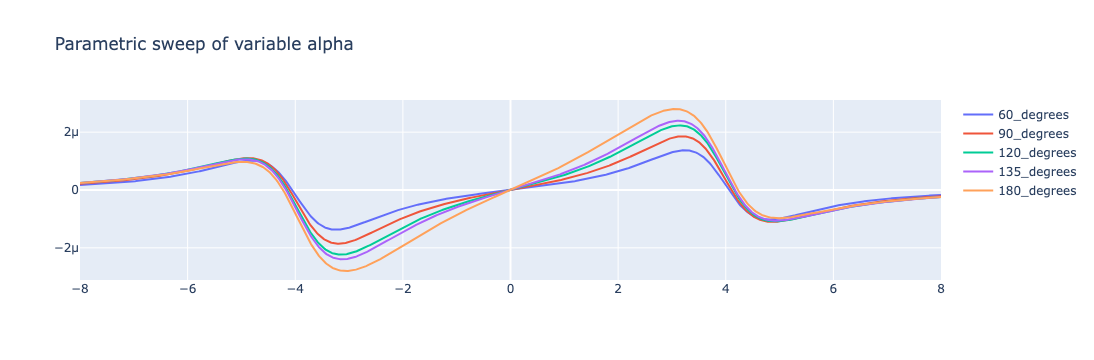

In [29]:
fig = go.Figure()
for alpha_test in alpha_parameters.values():

    x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l,alpha_test,d,s,current)
    Bx=x_gradient.getB(x_axis)


    
    name=list(alpha_parameters.keys())[list(alpha_parameters.values()).index(alpha_test)]

    fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f'{name}'))

fig.update_layout(title="Parametric sweep of variable alpha")
fig.show()

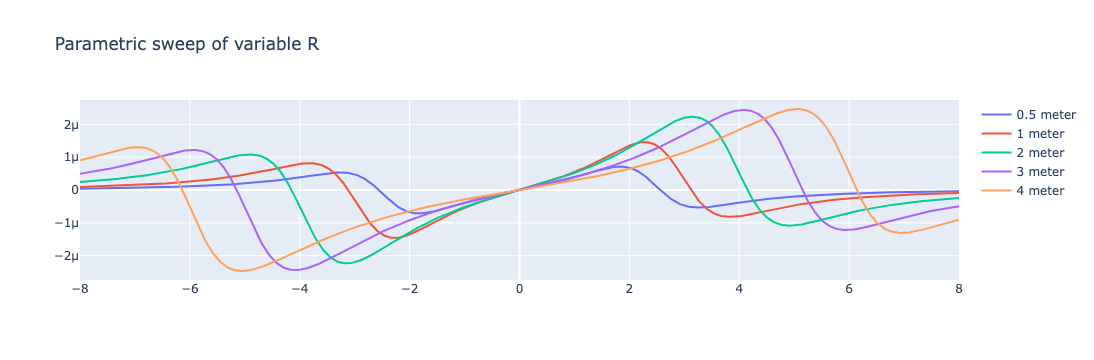

In [30]:
fig = go.Figure()
for R_test in R_parameters.values():

    x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R_test,l,alpha,d,s,current)
    Bx=x_gradient.getB(x_axis)


    
    name=list(R_parameters.keys())[list(R_parameters.values()).index(R_test)]

    fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f'{name}'))

fig.update_layout(title="Parametric sweep of variable R")
fig.show()

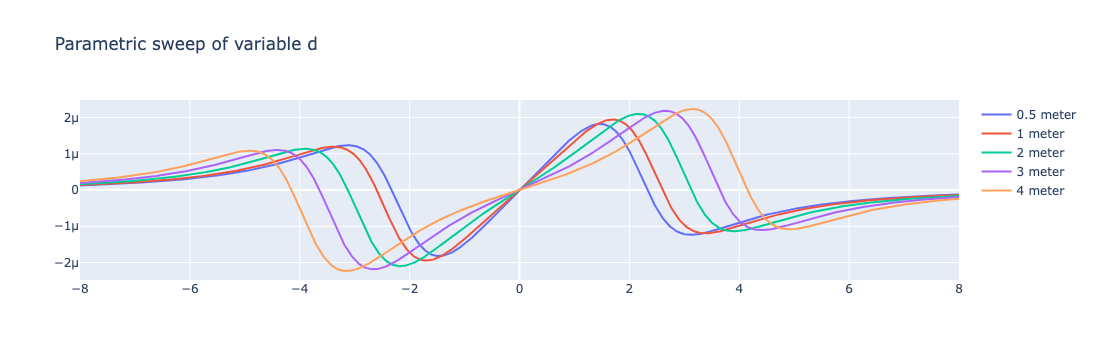

In [31]:
fig = go.Figure()
for d_test in d_parameters.values():

    x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l,alpha,d_test,s,current)
    Bx=x_gradient.getB(x_axis)


    
    name=list(d_parameters.keys())[list(d_parameters.values()).index(d_test)]

    fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f'{name}'))

fig.update_layout(title="Parametric sweep of variable d")
fig.show()

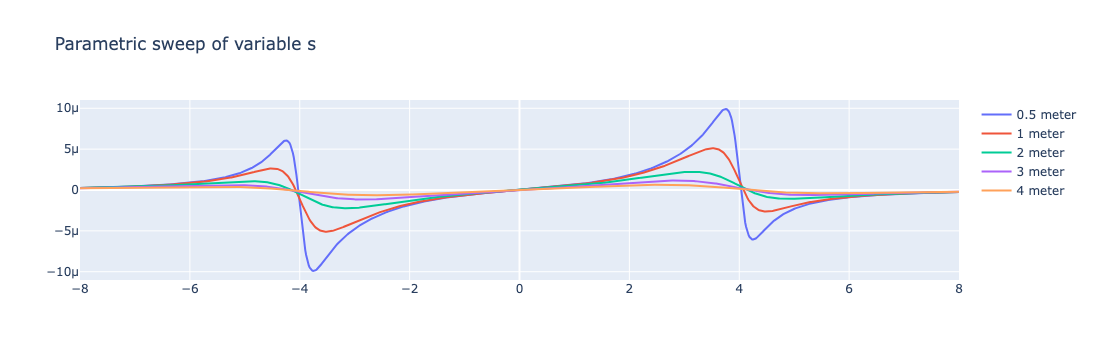

In [32]:
fig = go.Figure()
for s_test in s_parameters.values():

    x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l,alpha,d,s_test,current)
    Bx=x_gradient.getB(x_axis)


    
    name=list(s_parameters.keys())[list(s_parameters.values()).index(s_test)]

    fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f'{name}'))

fig.update_layout(title="Parametric sweep of variable s")
fig.show()

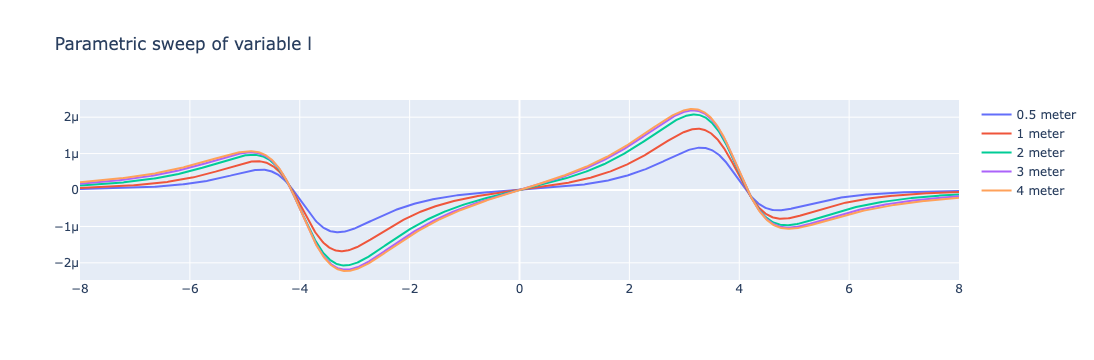

In [33]:
fig = go.Figure()
for l_test in l_parameters.values():

    x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l_test,alpha,d,s,current)
    Bx=x_gradient.getB(x_axis)


    
    name=list(l_parameters.keys())[list(l_parameters.values()).index(l_test)]

    fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f'{name}'))

fig.update_layout(title="Parametric sweep of variable l")
fig.show()

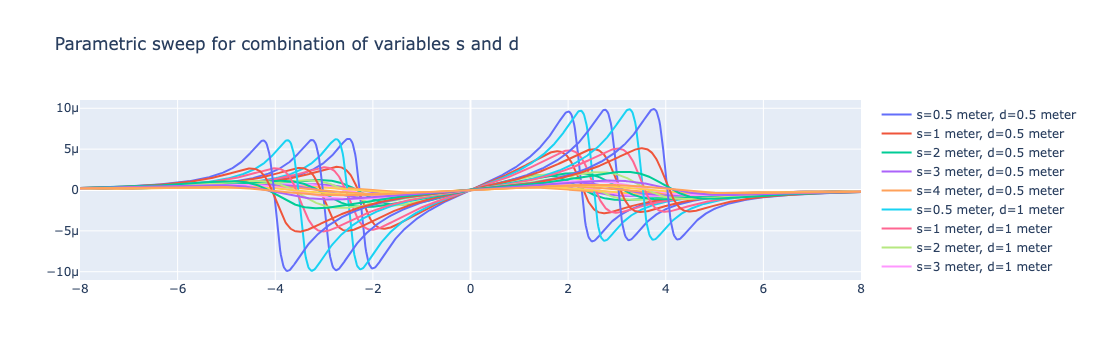

In [34]:
fig = go.Figure()

for d_test in d_parameters.values():

    name_d=list(d_parameters.keys())[list(d_parameters.values()).index(d_test)]
    
    for s_test in s_parameters.values():
    
        x_coil, x_gradient, y_coil, y_gradient=create_xy_gradients(R,l,alpha,d_test,s_test,current)        # set both s and d to s_test and d_test
        Bx=x_gradient.getB(x_axis)
        
        name_s=list(s_parameters.keys())[list(s_parameters.values()).index(s_test)]
    
        fig.add_trace(go.Scatter(x=x_axis[:,0], y=Bx[:,2], mode='lines', name=f's={name_s}, d={name_d}'))

fig.update_layout(title="Parametric sweep for combination of variables s and d")
fig.show()

In [ ]:
theta=np.linspace((np.pi-alpha)/2,alpha+(np.pi-alpha)/2,resolution)
x=R*np.cos(theta)
y=R*np.sin(theta)
z=np.zeros(resolution)
arc_1=np.stack((x,y,z),axis=1)
arc_2=translate(arc_1,0,0,l/2)
arc_1=translate(arc_1,0,0,-l/2)  # to make the origin right at the center

p1=arc_1[-1,:]
p2=arc_2[-1,:]
l1=np.linspace(p1,p2,resolution)
#l1=[p1,p2]
l1=np.vstack(l1)
p3=arc_2[0,:]
p4=arc_1[0,:]
l2=np.linspace(p3,p4,resolution)
#l2=[p3,p4]
l2=np.vstack(l2)
arc_2=arc_2[::-1]   # reverse to make the final connection correct
saddle_coordinates=[arc_1,l1,arc_2,l2]
saddle_coordinates=np.vstack(saddle_coordinates)

yc1=translate(saddle_coordinates,0,d/2,s/2+l/2)
yc4=translate(saddle_coordinates,0,d/2,-s/2-l/2)
yc2=mirror(yc1,'xz')
yc3=mirror(yc4,'xz')


y_coils=np.array([yc1,yc2,yc3,yc4])  #to get (4,n,3) shape, if vstack was used (4*n,3)
x_coils = rotate(y_coils, 'z')


currents=[-current,-current,current,current]

y_gradient_objects=[magpy.current.Polyline(current=I,vertices=V) for I,V in zip(currents,y_coils)]
y_gradient=magpy.Collection(*y_gradient_objects)

x_gradient_objects=[magpy.current.Polyline(current=I,vertices=V) for I,V in zip(currents,x_coils)]
x_gradient=magpy.Collection(*x_gradient_objects)
    
   
    

In [ ]:
fig = go.Figure()   #graph_objects then add traces



for i in range(0,4):
    fig.add_trace(go.Scatter3d(x=x_coils[i,:,0], y=x_coils[i,:,1], z=x_coils[i,:,2],name=f'X gradient coil {i+1}',line=dict(color='green', width=1)))
    fig.add_trace(go.Scatter3d(x=y_coils[i,:,0], y=y_coils[i,:,1], z=y_coils[i,:,2],name=f'Y gradient coil {i+1}',line=dict(color='red', width=1)))

fig.add_trace(go.Scatter3d(
    x=[-10, 10], y=[0, 0], z=[0, 0],
    mode='lines', line=dict(color='black', width=4), name='X-axis'
))

# Add Y-axis (Green)
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[-10, 10], z=[0, 0],
    mode='lines', line=dict(color='black', width=4), name='Y-axis'
))

# Add Z-axis (Blue)
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[-10, 10],
    mode='lines', line=dict(color='black', width=4), name='Z-axis'
))
    


fig.update_layout(
    scene=dict(
        # Set axis limits
        xaxis=dict(range=[-10, 10]),
        yaxis=dict(range=[-10, 10]),
        zaxis=dict(range=[-10, 10])
    ),
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),     # Y-axis points UP
        eye=dict(x=-2, y=1, z=2)    # Camera position
    )
)


fig.show(renderer='browser')